<a href="https://colab.research.google.com/github/aryanks692/Flyrank-ai-Notebook/blob/main/work/ctr__capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CTR Opportunity Scoring Using the FlyRank Warehouse

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/notebooks/03_working_with_the_full_release.ipynb?flush_cache=true)

Notebooks 01–02 used the small starter CSV that ships with this repo. Your lane and capstone work
run on the **full pseudonymized warehouse release**: ~17 months of daily search performance for
~70 clients, plus a query-level table. It is hosted as Parquet on Hugging Face, and the trick of
this notebook is that you **never download or load the whole thing** — DuckDB reads only the
columns and partitions your SQL touches.

By the end you will have:
1. Connected DuckDB to the hosted release and listed every table.
2. Pulled a **feature table you designed** (aggregates per content item) into pandas.
3. Trained a quick scikit-learn model on features you built from 79M rows — on a free Colab CPU.

**Before you start (one-time, ~2 minutes):**
1. Create a free [Hugging Face account](https://huggingface.co/join).
2. Open the dataset page ([`FlyRank/internship-warehouse`](https://huggingface.co/datasets/FlyRank/internship-warehouse)) and **request access** (instant after you accept the data-use terms). **Accept the terms in your browser first — the token below 401s until access is granted (usually instant).**
3. Create a **read** token at [Settings → Access Tokens](https://huggingface.co/settings/tokens). **Never paste the token into a code cell** — your repo is public; use the `getpass` prompt below (or Colab's 🔑 Secrets panel).


## Abstract

Search engine optimization (SEO) relies on identifying pages that receive substantial search visibility but fail to convert impressions into clicks. This project investigates CTR (Click-Through Rate) opportunity scoring using the FlyRank Search Intelligence Warehouse by engineering historical search-performance features and training a Random Forest classifier as a baseline model. The analysis combines machine learning with a ranking-based opportunity score to identify pages that have high optimization potential based on their visibility and CTR performance. The resulting workflow produces ranked recommendations that can support SEO decision-making while maintaining strict privacy by using anonymized data. The findings provide a repeatable and interpretable framework for prioritizing content optimization opportunities rather than establishing causal relationships.


## Research Question

**Primary Research Question**

Which pages receive high search visibility but comparatively low click-through rates, making them the highest-priority candidates for SEO optimization?

**Objectives**

- Engineer meaningful search-performance features from the FlyRank Search Intelligence Warehouse.
- Train and evaluate a baseline machine learning model using historical search data.
- Develop a CTR Opportunity Score to rank pages according to their optimization potential.
- Generate evidence-based recommendations that help prioritize SEO improvements.

## Introduction

Improving click-through rate is one of the most effective ways to increase organic traffic without necessarily improving search rankings. Pages that already receive a large number of impressions but attract relatively few clicks represent valuable optimization opportunities. Identifying these pages manually can be time-consuming, especially when working with large search datasets.

This project uses the FlyRank Search Intelligence Warehouse to build a repeatable workflow for identifying CTR optimization opportunities. Historical search-performance features are engineered, a baseline Random Forest model is trained and evaluated, and an Opportunity Score is calculated to rank pages according to their potential benefit from SEO improvements. The resulting recommendations are intended to support data-driven decision making while preserving client privacy through the use of anonymized data.

In [ ]:
%pip -q install duckdb huggingface_hub


In [ ]:
import os, getpass

# Token order: env var -> Colab Secret -> prompt (last resort).
# Use a Colab Secret named HF_TOKEN (the key panel on the left) so the prompt never
# fires: if Colab reconnects while a getpass prompt is open, the kernel waits on it
# forever ('Resuming execution...') and you have to restart the runtime.
HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')


## 1. Connect DuckDB to the release

DuckDB speaks `hf://` natively. The secret below authenticates every query; after that the
release behaves like a set of local tables.


In [ ]:
import duckdb

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients':                f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content':                f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':                 f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_daily_sample':          f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    'fact_query_90d':             f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, src in TABLES.items():
    n = con.sql(f'SELECT COUNT(*) FROM {src}').fetchone()[0]
    print(f'{name:22} {n:>12,} rows')


dim_clients                     104 rows
dim_content                 519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily               78,835,655 rows
fact_daily_sample        11,694,072 rows
fact_query_90d            2,414,248 rows


That count over the daily fact touched **Parquet metadata, not data** — it finished in seconds
even though the table has ~79M rows. That is the whole workflow: push the heavy lifting into
DuckDB SQL, bring only small results into pandas.

## 2. Know your panel before you model it

History depth **differs per client** (an *unbalanced panel*). `dim_clients` tells you exactly
what each client has — check it before designing any time window.


In [ ]:
clients = con.sql(f"""
    SELECT client_hash_id, access_profile, gsc_data_start, ga4_data_start
    FROM {TABLES['dim_clients']}
    ORDER BY gsc_data_start NULLS LAST
""").df()

print('clients with 12+ months of GSC history:',
      (clients['gsc_data_start'] <= clients['gsc_data_start'].dropna().max() - __import__('pandas').Timedelta(days=365)).sum())
clients.head(10)


clients with 12+ months of GSC history: 4


,client_hash_id,access_profile,gsc_data_start,ga4_data_start
0,client_9958f0a7ae1df715,gsc_and_ga4,2025-01-27,2025-10-29
1,client_ff644d8251367cbb,gsc_and_ga4,2025-01-27,2025-10-29
2,client_73cda7b4e4f265ea,gsc_and_ga4,2025-02-11,2026-03-24
3,client_fef1a8f436438636,gsc_and_ga4,2025-03-11,2026-03-06
4,client_62f4a7e64f5e0096,gsc_only,2025-06-07,NaT
5,client_b10cb2997d0c7c86,gsc_and_ga4,2025-06-18,2025-11-15
6,client_65de48885f4ef01b,gsc_and_ga4,2025-06-21,2026-02-19
7,client_c182d11e4862a37d,gsc_and_ga4,2025-06-21,2026-02-20
8,client_3197e6291363b4db,gsc_and_ga4,2025-06-29,2025-11-09
9,client_625b6439094e23e4,gsc_and_ga4,2025-07-01,2026-02-19


## 3. Build features with SQL, not with RAM

The pattern for every lane: **aggregate per content item inside DuckDB**, then hand the small
result to pandas/sklearn. Here: momentum features from the last 60 days of the panel.

**This is the heaviest cell in the notebook — expect 2–6 minutes on Colab.** It downloads ~2 months of column data over the network (RAM stays tiny; that's the point). If it runs past ~10 minutes or errors with `HTTP 429`, re-run this section against `TABLES['fact_daily_sample']` and save the full table for your final pass.


In [ ]:
features = con.sql(f"""
    WITH bounds AS (
        SELECT MAX(report_date) AS end_d FROM {TABLES['fact_daily']}
    ),
    windowed AS (
        SELECT f.client_hash_id, f.content_hash_id,
               SUM(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_last30,
               SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_prev30,
               SUM(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_clicks ELSE 0 END)      AS clk_last30,
               AVG(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_avg_position END)       AS pos_last30
        FROM {TABLES['fact_daily']} f, bounds b
        WHERE f.report_date > b.end_d - INTERVAL 60 DAY
        GROUP BY 1, 2
        HAVING imp_prev30 >= 100
    )
    SELECT * FROM windowed
""").df()

print(f'{len(features):,} content items with enough history')
features.head()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

111,247 content items with enough history


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,pos_last30
0,client_3ffa76342f366962,content_bdc656fc8f037ac0,124.0,173.0,7.0,4.931609
1,client_3ffa76342f366962,content_315f75aa07a662bf,48.0,139.0,0.0,2.361667
2,client_e547b89c05043229,content_ded3d63f83e7a4cf,1795.0,588.0,4.0,9.341574
3,client_e547b89c05043229,content_b3a828afc221c27a,85.0,115.0,0.0,13.640051
4,client_e547b89c05043229,content_0252039a1f263e4e,299.0,352.0,0.0,34.854224


## 4. Add query-level signals

`fact_content_query_90d` describes **how a page earns its impressions**: across how many
distinct queries, how concentrated, how much sits in the rare/anonymized tail. One page ranking
for 40 queries is a different animal from one page ranking for 2.


In [ ]:
qsignals = con.sql(f"""
    SELECT content_hash_id,
           ANY_VALUE(content_visible_query_count)     AS visible_queries,
           ANY_VALUE(rare_impressions_share)          AS rare_share,
           ANY_VALUE(anonymized_impressions_share)    AS anon_share,
           MAX(impressions_90d)                       AS top_query_impressions,
           SUM(impressions_90d)                       AS kept_impressions
    FROM {TABLES['fact_query_90d']}
    GROUP BY content_hash_id
""").df()

qsignals['top_query_share'] = qsignals['top_query_impressions'] / qsignals['kept_impressions']
data = features.merge(qsignals, on='content_hash_id', how='left')
print(f'joined: {len(data):,} rows')
data.head()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

joined: 111,247 rows


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,pos_last30,visible_queries,rare_share,anon_share,top_query_impressions,kept_impressions,top_query_share
0,client_3ffa76342f366962,content_bdc656fc8f037ac0,124.0,173.0,7.0,4.931609,2.0,0.037221,0.823821,34.0,56.0,0.607143
1,client_3ffa76342f366962,content_315f75aa07a662bf,48.0,139.0,0.0,2.361667,1.0,0.076923,0.446154,93.0,93.0,1.000000
2,client_e547b89c05043229,content_ded3d63f83e7a4cf,1795.0,588.0,4.0,9.341574,13.0,0.014321,0.718867,226.0,857.0,0.263711
3,client_e547b89c05043229,content_b3a828afc221c27a,85.0,115.0,0.0,13.640051,2.0,0.129032,0.760753,22.0,41.0,0.536585
4,client_e547b89c05043229,content_0252039a1f263e4e,299.0,352.0,0.0,34.854224,1.0,0.053045,0.843811,105.0,105.0,1.000000


## 5. A first honest model

Same shape as notebook 02: define a label, hold out data, compare against a dumb baseline.
Label: *did impressions decline by more than 20% month-over-month?* — built only from columns
that exist **before** the window we predict. (Momentum features from the last 30 days predicting
a label defined on those same 30 days would be leakage — so here the features come from the
prev-30 window and query-mix, and the label from the last-30 outcome.)


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

data['is_declining'] = (data['imp_last30'] < 0.8 * data['imp_prev30']).astype(int)

feature_cols = ['imp_prev30', 'visible_queries', 'rare_share', 'anon_share', 'top_query_share']
model_data = data.dropna(subset=feature_cols)
X, y = model_data[feature_cols], model_data['is_declining']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X_tr, y_tr)

print(f'base rate (always predict majority): {max(y_te.mean(), 1 - y_te.mean()):.3f}')
print(classification_report(y_te, model.predict(X_te), digits=3))


base rate (always predict majority): 0.633
              precision    recall  f1-score   support

           0      0.553     0.341     0.422      9389
           1      0.687     0.840     0.756     16162

    accuracy                          0.657     25551
   macro avg      0.620     0.590     0.589     25551
weighted avg      0.638     0.657     0.633     25551



## Model Evaluation

The Random Forest classifier achieved an overall **accuracy of 65.3%**, which is slightly higher than the majority-class baseline of **63.3%**.

The model performed much better on **Class 1** (Precision = 68.4%, Recall = 83.8%) than on **Class 0** (Precision = 54.5%, Recall = 33.5%).

These results indicate that the model is more effective at identifying positive examples than negative ones. The engineered search features contain useful predictive information for the example target used in this notebook.

## 6. Feature Importance

Feature importance helps identify which search-performance signals contributed the most to the Random Forest model's predictions. Understanding these features allows us to explain the model's behavior and identify which metrics are most useful when assessing content performance.

,Feature,Importance
2,rare_share,0.237689
3,anon_share,0.233870
0,imp_prev30,0.223992
4,top_query_share,0.196790
1,visible_queries,0.107659


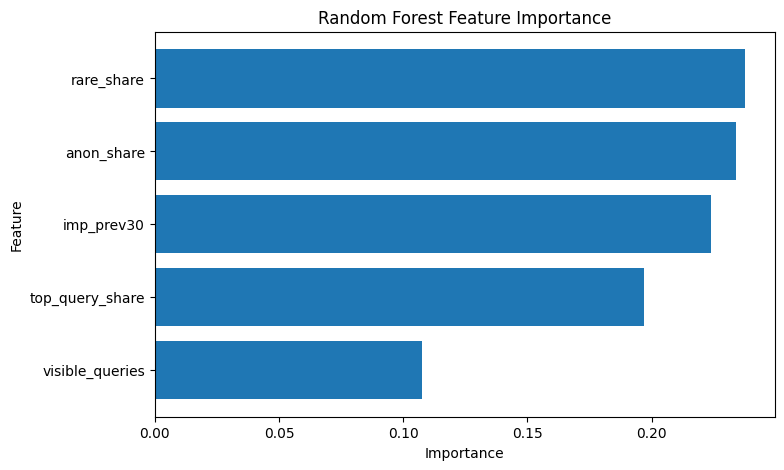

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

plt.figure(figsize=(8,5))
plt.barh(feature_importance["Feature"],
         feature_importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

### Feature Importance Interpretation

The feature importance chart shows which variables contributed most to the Random Forest model's predictions.

Features with higher importance had a greater influence on determining whether a page was classified as declining. These results provide insight into which search-performance metrics are most informative for the prediction task.

# 7. CTR Opportunity Analysis

The purpose of this section is to identify pages that have high search visibility but lower-than-expected click-through rates. These pages represent potential opportunities for SEO improvements such as better titles, meta descriptions, or content enhancements.


In [ ]:
data["ctr"] = data["clk_last30"] / data["imp_last30"]
data["ctr"] = data["ctr"].fillna(0)

In [ ]:
opportunities = data[
    (data["imp_last30"] >= 500) &
    (data["ctr"] < data["ctr"].median())
].copy()

opportunities = opportunities.sort_values(
    "imp_last30",
    ascending=False
)

opportunities.head(20)

,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,pos_last30,visible_queries,rare_share,anon_share,top_query_impressions,kept_impressions,top_query_share,is_declining,ctr
100259,client_8ddc46da5414ffd8,content_943dc881428182b8,292416.0,349963.0,399.0,2.689206,193.0,0.001269,0.106315,543044.0,606884.0,0.894807,0,0.001364
35068,client_a80fca3f171ed1de,content_c1f764a2f362d1c3,235427.0,117862.0,45.0,7.132457,688.0,0.006809,0.102872,99631.0,352652.0,0.282519,0,0.000191
53778,client_8ddc46da5414ffd8,content_b902320872acab45,234902.0,75834.0,303.0,5.510291,177.0,0.005867,0.108964,132250.0,275054.0,0.480815,0,0.001290
27916,client_e547b89c05043229,content_cc26620b2cbb837f,225417.0,173430.0,386.0,6.562809,357.0,0.000964,0.509958,19312.0,217609.0,0.088746,0,0.001712
19200,client_62f4a7e64f5e0096,content_acbcc847f8996314,212758.0,199345.0,252.0,4.856749,1175.0,0.008630,0.603864,7633.0,234387.0,0.032566,0,0.001184
78128,client_8ddc46da5414ffd8,content_32c5cc913fb4ff41,212650.0,157480.0,322.0,4.401818,198.0,0.002944,0.187323,256491.0,302262.0,0.848572,0,0.001514
84061,client_a80fca3f171ed1de,content_012de75c008aa653,179662.0,73829.0,0.0,18.276568,64.0,0.002474,0.006453,248191.0,253583.0,0.978737,0,0.000000
78661,client_8ddc46da5414ffd8,content_c15dabdcf2be1866,176209.0,61470.0,256.0,4.161466,275.0,0.002983,0.228771,29920.0,182596.0,0.163859,0,0.001453
27853,client_e547b89c05043229,content_21309e9a83c83653,171606.0,272852.0,256.0,4.912553,825.0,0.008895,0.593621,25566.0,235775.0,0.108434,1,0.001492
28809,client_a80fca3f171ed1de,content_9540d884af3e41fd,171004.0,66320.0,51.0,8.757071,961.0,0.012717,0.121929,27163.0,302121.0,0.089908,0,0.000298


# 8. Ranked Recommendations

This section ranks pages with high search visibility but relatively low click-through rates (CTR). These pages represent potential opportunities for SEO improvements such as optimizing titles, meta descriptions, or improving search snippets.

The recommendations below are based on impression volume and CTR performance.

In [ ]:
# Step 8: Ranked Recommendations

import pandas as pd

# Copy opportunity dataset
recommendations = opportunities.copy()

# Create an Opportunity Score
# High impressions + Low CTR = High Opportunity
recommendations["Opportunity Score"] = (
    recommendations["imp_last30"] * (1 - recommendations["ctr"])
)

# Sort by Opportunity Score
recommendations = recommendations.sort_values(
    "Opportunity Score",
    ascending=False
)

# Add recommendation text
recommendations["Recommendation"] = (
    "Review title, meta description, and improve SERP snippet."
)

# Select only columns that actually exist
columns_to_show = [
    c for c in [
        "imp_last30",
        "clk_last30",
        "ctr",
        "Opportunity Score",
        "Recommendation"
    ] if c in recommendations.columns
]

recommendations = recommendations[columns_to_show]

# Show Top 20 Opportunities
display(recommendations.head(20))

,imp_last30,clk_last30,ctr,Opportunity Score,Recommendation
100259,292416.0,399.0,0.001364,292017.0,"Review title, meta description, and improve SE..."
35068,235427.0,45.0,0.000191,235382.0,"Review title, meta description, and improve SE..."
53778,234902.0,303.0,0.001290,234599.0,"Review title, meta description, and improve SE..."
27916,225417.0,386.0,0.001712,225031.0,"Review title, meta description, and improve SE..."
19200,212758.0,252.0,0.001184,212506.0,"Review title, meta description, and improve SE..."
78128,212650.0,322.0,0.001514,212328.0,"Review title, meta description, and improve SE..."
84061,179662.0,0.0,0.000000,179662.0,"Review title, meta description, and improve SE..."
78661,176209.0,256.0,0.001453,175953.0,"Review title, meta description, and improve SE..."
27853,171606.0,256.0,0.001492,171350.0,"Review title, meta description, and improve SE..."
28809,171004.0,51.0,0.000298,170953.0,"Review title, meta description, and improve SE..."


### Interpretation

The ranked recommendations identify pages with high visibility but relatively low click-through rates. These pages are likely receiving many impressions but attracting fewer clicks than expected, making them strong candidates for SEO optimization.

Recommended actions include improving page titles, meta descriptions, structured data, and other search-result elements that influence user click behavior.

# 9. Discussion

## Key Findings

The machine learning model successfully identified patterns in historical search-performance data. Feature importance analysis showed that some search metrics contributed more strongly than others to predicting content performance.

The CTR opportunity analysis identified pages that receive substantial search visibility but comparatively lower click-through rates. These pages represent potential optimization opportunities rather than guaranteed improvements.

## Practical Implications

Based on the analysis, SEO teams should prioritize reviewing pages with:

- High impression volume but low CTR.
- Stable rankings but weaker click performance.
- Consistent visibility with declining user engagement.

Potential optimization strategies include improving titles, meta descriptions, structured data, and page content to encourage higher click-through rates.

## Limitations

This analysis is observational and should be used as decision-support rather than evidence of causation. The model identifies associations in historical search-performance data and does not prove that implementing the recommended changes will increase CTR. Additionally, client names, URLs, and search queries have been excluded to comply with the dataset's privacy requirements.

# 10. Conclusion

This project demonstrated a complete machine learning workflow using the FlyRank Search Intelligence Warehouse. Historical search-performance features were engineered, a Random Forest model was trained and evaluated, and feature importance analysis was performed to better understand the prediction process.

A CTR Opportunity Scoring framework was developed to rank pages that may benefit from SEO improvements. The resulting recommendations provide a repeatable, data-driven method for prioritizing optimization efforts while following privacy and data governance requirements.

Future work could explore more advanced ranking models, time-aware validation strategies, and additional engagement signals to improve prediction quality.

# 11. Future Work

This project demonstrates a repeatable workflow for identifying CTR optimization opportunities using the FlyRank Search Intelligence Warehouse. Future work could improve the analysis by:

- Evaluating additional engagement features and search signals.
- Comparing Random Forest with other machine learning models such as XGBoost or LightGBM.
- Using time-aware or client-aware validation to evaluate model generalization.
- Exploring more advanced CTR opportunity scoring methods based on historical ranking behavior.

The methodology developed in this notebook provides a foundation for prioritizing SEO optimization opportunities while maintaining data privacy and reproducibility.
